CELL 1 — Distribusi Label (Class Balance)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

Dataset HTRU2 memiliki distribusi kelas yang imbalanced, di mana kelas 0 (non-pulsar) jauh lebih banyak daripada kelas 1 (pulsar).
Ini wajar karena pulsar adalah objek langka di astronomi.

CELL 2 — Histogram Setiap Fitur (Distribusi Data)

In [2]:
df = pd.read_csv("HTRU_2.csv", header=None)

df.columns = [
    "mean_profile",
    "std_profile",
    "skewness_profile",
    "kurtosis_profile",
    "mean_dm_snr",
    "std_dm_snr",
    "skewness_dm_snr",
    "kurtosis_dm_snr",
    "class"
]

df.head()

,mean_profile,std_profile,skewness_profile,kurtosis_profile,mean_dm_snr,std_dm_snr,skewness_dm_snr,kurtosis_dm_snr,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


CELL 3 — Boxplot Fitur (Deteksi Outlier)

In [3]:
X = df.drop(columns=["class"])
y = df["class"]

CELL 4 — Heatmap Korelasi Antar Fitur

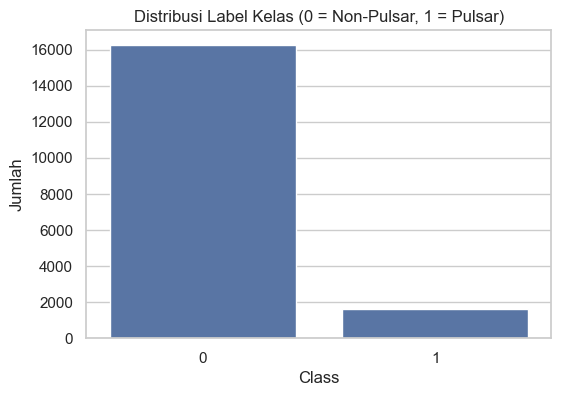

class
0    16259
1     1639
Name: count, dtype: int64

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Distribusi Label Kelas (0 = Non-Pulsar, 1 = Pulsar)")
plt.xlabel("Class")
plt.ylabel("Jumlah")
plt.show()

y.value_counts()

CELL 5 — Pairplot (Opsional, Lama Diproses)

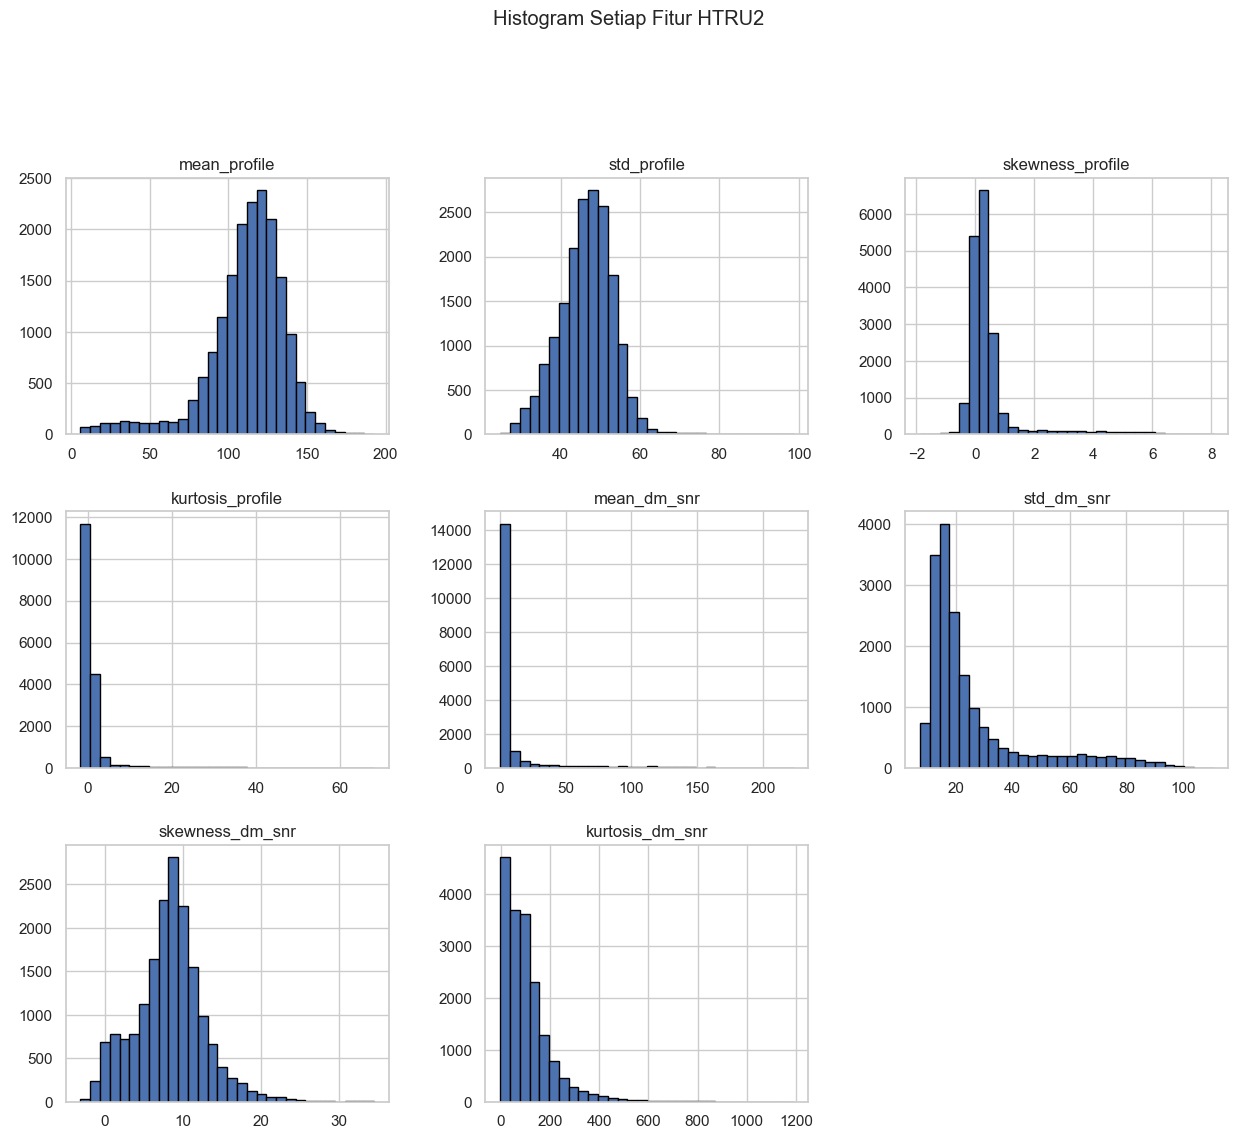

In [5]:
df.drop(columns=["class"]).hist(
    bins=30, figsize=(15,12), edgecolor='black'
)
plt.suptitle("Histogram Setiap Fitur HTRU2", y=1.02)
plt.show()

CELL 6 — PCA untuk Visualisasi 2D

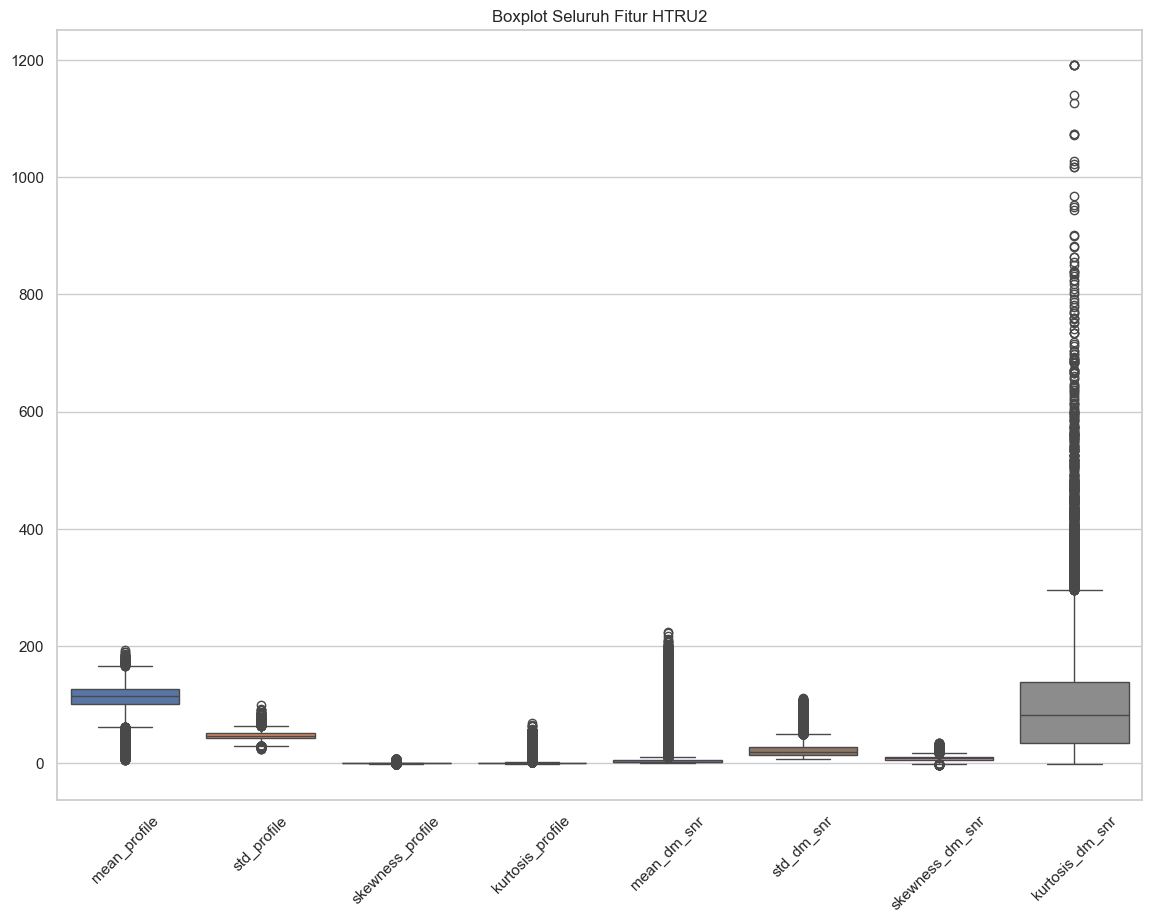

In [6]:
plt.figure(figsize=(14,10))
sns.boxplot(data=df.drop(columns=["class"]))
plt.title("Boxplot Seluruh Fitur HTRU2")
plt.xticks(rotation=45)
plt.show()

Exploratory Data Analysis dilakukan untuk memahami karakteristik awal dari dataset HTRU2.
Dari hasil analisis, diperoleh beberapa temuan penting:
	1.	Distribusi label sangat imbalanced, dengan kelas non-pulsar (0) jauh lebih banyak daripada kelas pulsar (1).
	2.	Distribusi fitur bersifat skewed dan memiliki banyak outlier, namun outlier tidak dihapus karena merupakan bagian alami dari sinyal radio.
	3.	Korelasi antar fitur relatif kecil sehingga setiap fitur memiliki kontribusi yang cukup independen.
	4.	PCA dua dimensi menunjukkan bahwa terdapat pola pemisahan antara sinyal pulsar dan non-pulsar, meskipun tidak sempurna.

Temuan-temuan ini menjadi dasar kuat untuk pemilihan metode klasifikasi (Decision Tree) dan metode clustering pada tahap analisis berikutnya.

CELL 7 — Heatmap Korelasi

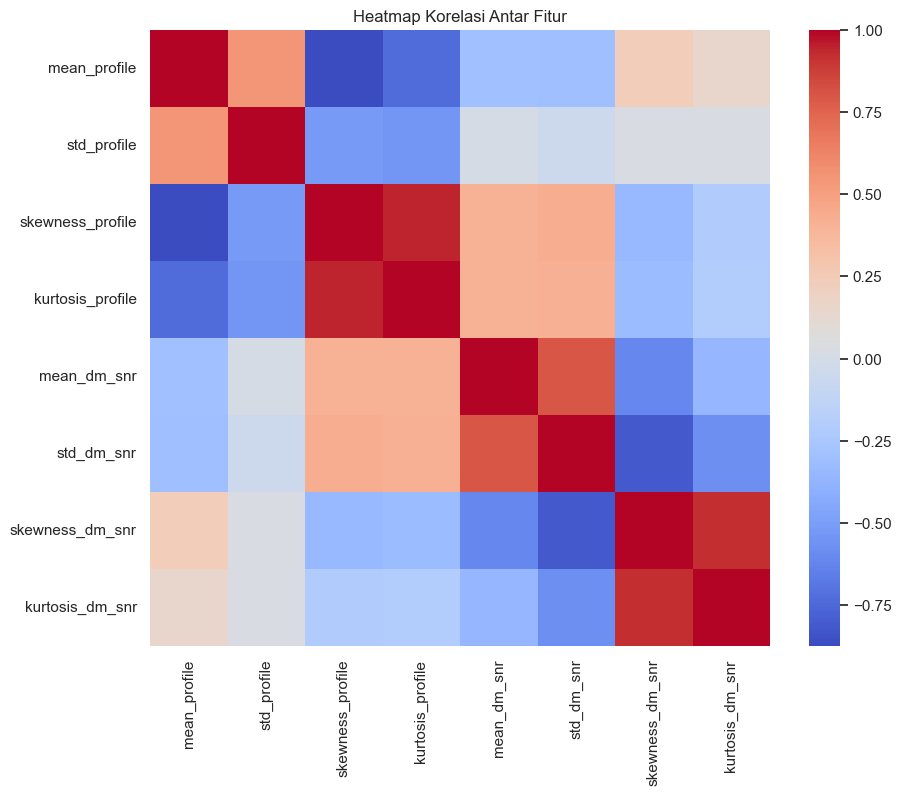

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=["class"]).corr(), 
            annot=False, cmap="coolwarm")
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

CELL 8 — PCA Visualisasi 2D

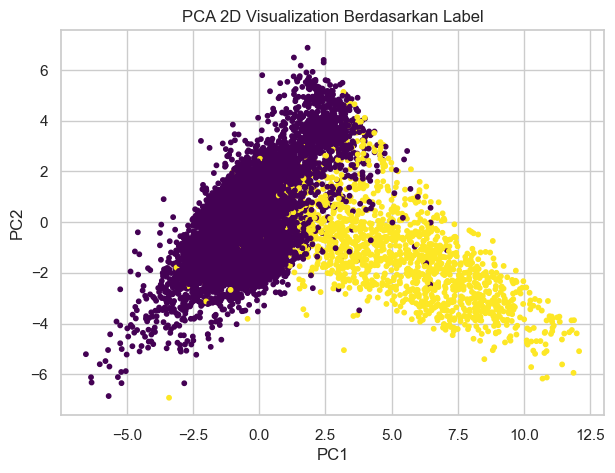

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(pca_data[:,0], pca_data[:,1], 
            c=y, cmap="viridis", s=10)

plt.title("PCA 2D Visualization Berdasarkan Label")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()